# Analyse d'erreurs du run002

Ce notebook explore les sorties du run `dinov3-vitb16_run002` stockées dans `runpod_results/run002`.

Attention : ce dossier contient les prédictions de soumission et le log du run, mais pas de labels de validation. L'analyse ci-dessous combine donc :

- les métriques agrégées du run ;
- la distribution des prédictions ;
- des proxys d'erreur basés sur la structure des noms de fichiers ;
- des comparaisons avec la distribution des labels d'entraînement pour préparer les itérations suivantes.


In [ ]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
RUN_DIR = ROOT / 'runpod_results' / 'run002'
LOG_PATH = RUN_DIR / 'dinov3-vitb16_run002.md'
PRED_PATH = RUN_DIR / 'dinov3-vitb16_run002.csv'
TRAIN_CSV = ROOT / 'occlusion_datasets' / 'train.csv'


def parse_kv_log(path: Path) -> dict:
    info = {}
    for line in path.read_text(encoding='utf-8').splitlines():
        if ': ' in line:
            key, value = line.split(': ', 1)
            info[key.strip()] = value.strip()
    return info


def parse_filename_features(filename: str) -> dict:
    parts = Path(filename).parts
    root_db = next((part for part in parts if part.startswith('database')), 'unknown')
    face_id_match = re.search(r'FaceId-(\d+)', filename)
    face_id = int(face_id_match.group(1)) if face_id_match else np.nan
    face_tag = 'FaceId-' + str(face_id) if not np.isnan(face_id) else 'unknown'
    return {
        'database_root': root_db,
        'face_id': face_id,
        'face_tag': face_tag,
        'source_branch': parts[0] if parts else 'unknown',
    }


run_info = parse_kv_log(LOG_PATH)
preds = pd.read_csv(PRED_PATH)
train = pd.read_csv(TRAIN_CSV)

preds = preds.rename(columns={'FaceOcclusion': 'pred'})
preds = pd.concat([preds, preds['filename'].apply(parse_filename_features).apply(pd.Series)], axis=1)
train = pd.concat([train, train['filename'].apply(parse_filename_features).apply(pd.Series)], axis=1)

print('Run metadata')
for key in ['run', 'model', 'epochs', 'batch_size', 'lr', 'scheduler', 'min_lr', 'val_every', 'validation_balanced_metric', 'validation_error']:
    if key in run_info:
        print(f'{key}: {run_info[key]}')

print('\nShapes')
print('preds:', preds.shape)
print('train:', train.shape)
print('\nPrediction columns:', preds.columns.tolist())
print('\nPrediction head:')
display(preds.head())

In [2]:
pred_summary = preds['pred'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print('Prediction summary')
display(pred_summary.to_frame(name='value'))

print('\nShare above thresholds')
for threshold in [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    share = (preds['pred'] >= threshold).mean()
    print(f'>= {threshold:0.2f}: {share:.2%}')

print('\nTop 10 highest predictions')
display(preds.sort_values('pred', ascending=False).head(10)[['filename', 'pred', 'database_root', 'face_tag']])

print('\nTop 10 lowest predictions')
display(preds.sort_values('pred', ascending=True).head(10)[['filename', 'pred', 'database_root', 'face_tag']])

Prediction summary


,value
count,29980.000000
mean,0.169466
std,0.104253
min,0.004112
1%,0.010071
5%,0.016741
10%,0.028271
25%,0.080710
50%,0.164647
75%,0.249127



Share above thresholds
>= 0.01: 99.04%
>= 0.02: 93.37%
>= 0.05: 83.49%
>= 0.10: 69.68%
>= 0.20: 39.50%
>= 0.30: 12.61%
>= 0.50: 0.03%

Top 10 highest predictions


,filename,pred,database_root,face_tag
29973,database3/database3/m.01ptr37/82-FaceId-0_alig...,0.572814,database3,FaceId-0
29725,database3/database3/m.0132k4/102-FaceId-0_alig...,0.562316,database3,FaceId-0
29946,database3/database3/m.025sf_8/43-FaceId-0_alig...,0.543397,database3,FaceId-0
29971,database2/database2/test/43.webp,0.535463,database2,unknown
29743,database3/database3/m.01pz7lt/80-FaceId-0_alig...,0.534907,database3,FaceId-0
28979,database3/database3/m.01vrqb3/63-FaceId-0_alig...,0.524133,database3,FaceId-0
29943,database3/database3/m.01mz1r/8-FaceId-0_align....,0.514516,database3,FaceId-0
29937,database3/database3/m.01p0fvs/12-FaceId-0_alig...,0.513873,database3,FaceId-0
29959,database3/database3/m.01rzvh2/101-FaceId-0_ali...,0.513269,database3,FaceId-0
29957,database3/database3/m.01w02sy/47-FaceId-0_alig...,0.505575,database3,FaceId-0



Top 10 lowest predictions


,filename,pred,database_root,face_tag
1255,database3/database3/m.018ptv/28-FaceId-0_align...,0.004112,database3,FaceId-0
957,database3/database3/m.018thc/4-FaceId-0_align....,0.005753,database3,FaceId-0
2457,database3/database3/m.01m5y4b/16-FaceId-0_alig...,0.006044,database3,FaceId-0
3092,database3/database3/m.01w4h_/27-FaceId-0_align...,0.006118,database3,FaceId-0
3158,database3/database3/m.02crc4/22-FaceId-0_align...,0.006357,database3,FaceId-0
1034,database3/database3/m.027fxnv/54-FaceId-0_alig...,0.006408,database3,FaceId-0
1540,database3/database3/m.018gl5/21-FaceId-0_align...,0.006513,database3,FaceId-0
2275,database3/database3/m.01g562/26-FaceId-0_align...,0.006540,database3,FaceId-0
4255,database3/database3/m.02j8rx/8-FaceId-0_align....,0.006545,database3,FaceId-0
1975,database3/database3/m.01dk_/68-FaceId-0_align....,0.006781,database3,FaceId-0


In [3]:
pred_group_stats = (
    preds.groupby(['database_root', 'face_tag'])['pred']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .sort_values(['database_root', 'count'], ascending=[True, False])
)

train_group_stats = (
    train.groupby(['database_root', 'face_tag'])['FaceOcclusion']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .rename(columns={'FaceOcclusion': 'target'})
    .sort_values(['database_root', 'count'], ascending=[True, False])
)

print('Prediction means by database root')
display(preds.groupby('database_root')['pred'].agg(['count', 'mean', 'std']).sort_values('count', ascending=False))

print('\nTraining label means by database root')
display(train.groupby('database_root')['FaceOcclusion'].agg(['count', 'mean', 'std']).sort_values('count', ascending=False))

print('\nPrediction means by FaceId tag')
display(preds.groupby('face_tag')['pred'].agg(['count', 'mean', 'std']).sort_values('count', ascending=False))

print('\nLargest database_root / face_tag groups in predictions')
display(pred_group_stats.head(20))

print('\nCorresponding training label stats')
display(train_group_stats.loc[pred_group_stats.head(20).index.intersection(train_group_stats.index)])

Prediction means by database root


,count,mean,std
database_root,,,
database3,28435,0.167984,0.104031
database1,1427,0.192225,0.100619
database2,118,0.251311,0.133366



Training label means by database root


,count,mean,std
database_root,,,
database3,96023,0.081416,0.085684
database1,3747,0.112949,0.098331
database2,230,0.134692,0.123177



Prediction means by FaceId tag


,count,mean,std
face_tag,,,
FaceId-0,27487,0.168455,0.104062
unknown,1545,0.196738,0.104617
FaceId-1,759,0.151162,0.102105
FaceId-2,111,0.174072,0.103146
FaceId-3,41,0.158655,0.111660
FaceId-4,15,0.136954,0.072184
FaceId-6,5,0.122590,0.092425
FaceId-9,4,0.129578,0.032160
FaceId-5,4,0.152526,0.099347



Largest database_root / face_tag groups in predictions


count      mean       std       min    median  \
database_root face_tag                                                   
database1     unknown     1427  0.192225  0.100619  0.007196  0.185788   
database2     unknown      118  0.251311  0.133366  0.010703  0.248283   
database3     FaceId-0   27487  0.168455  0.104062  0.004112  0.163779   
              FaceId-1     759  0.151162  0.102105  0.007432  0.137061   
              FaceId-2     111  0.174072  0.103146  0.006868  0.168623   
              FaceId-3      41  0.158655  0.111660  0.011350  0.124598   
              FaceId-4      15  0.136954  0.072184  0.021614  0.136233   
              FaceId-6       5  0.122590  0.092425  0.019943  0.081617   
              FaceId-5       4  0.152526  0.099347  0.037747  0.150336   
              FaceId-9       4  0.129578  0.032160  0.089878  0.134702   
              FaceId-7       3  0.169082  0.113784  0.041011  0.207720   
              FaceId-11      1  0.288596       NaN  0.288596  0.288596   
              FaceId-14      1  0.295243       NaN  0.295243  0.295243   
              FaceId-18      1  0.040854       NaN  0.040854  0.040854   
              FaceId-48      1  0.223220       NaN  0.223220  0.223220   
              FaceId-63      1  0.255159       NaN  0.255159  0.255159   
              FaceId-8       1  0.338113       NaN  0.338113  0.338113   

                              max  
database_root face_tag             
database1     unknown    0.462837  
database2     unknown    0.535463  
database3     FaceId-0   0.572814  
              FaceId-1   0.460089  
              FaceId-2   0.391768  
              FaceId-3   0.376173  
              FaceId-4   0.262738  
              FaceId-6   0.225829  
              FaceId-5   0.271687  
              FaceId-9   0.159031  
              FaceId-7   0.258516  
              FaceId-11  0.288596  
              FaceId-14  0.295243  
              FaceId-18  0.040854  
              FaceId-48  0.223220  
              FaceId-63  0.255159  
              FaceId-8   0.338113


Corresponding training label stats


count      mean       std       min    median  \
database_root face_tag                                                   
database1     unknown     3747  0.112949  0.098331  0.000000  0.090992   
database2     unknown      230  0.134692  0.123177  0.000000  0.099341   
database3     FaceId-0   92614  0.081494  0.085723  0.000000  0.048508   
              FaceId-1    2726  0.078818  0.083199  0.000000  0.047112   
              FaceId-2     418  0.077579  0.084491  0.000000  0.050765   
              FaceId-3     121  0.074560  0.088746  0.000000  0.046206   
              FaceId-4      70  0.095658  0.090168  0.000000  0.068016   
              FaceId-6      11  0.093389  0.090458  0.018184  0.043478   
              FaceId-5      30  0.075587  0.087784  0.000000  0.042200   
              FaceId-9       2  0.184888  0.089238  0.121788  0.184888   
              FaceId-7       7  0.053086  0.041007  0.013854  0.038637   
              FaceId-11      1  0.031961       NaN  0.031961  0.031961   
              FaceId-14      1  0.123708       NaN  0.123708  0.123708   
              FaceId-8       4  0.150891  0.159490  0.022613  0.102351   

                              max  
database_root face_tag             
database1     unknown    0.564084  
database2     unknown    0.641248  
database3     FaceId-0   1.000000  
              FaceId-1   0.615254  
              FaceId-2   0.588833  
              FaceId-3   0.420918  
              FaceId-4   0.322847  
              FaceId-6   0.309774  
              FaceId-5   0.346278  
              FaceId-9   0.247989  
              FaceId-7   0.128399  
              FaceId-11  0.031961  
              FaceId-14  0.123708  
              FaceId-8   0.376246

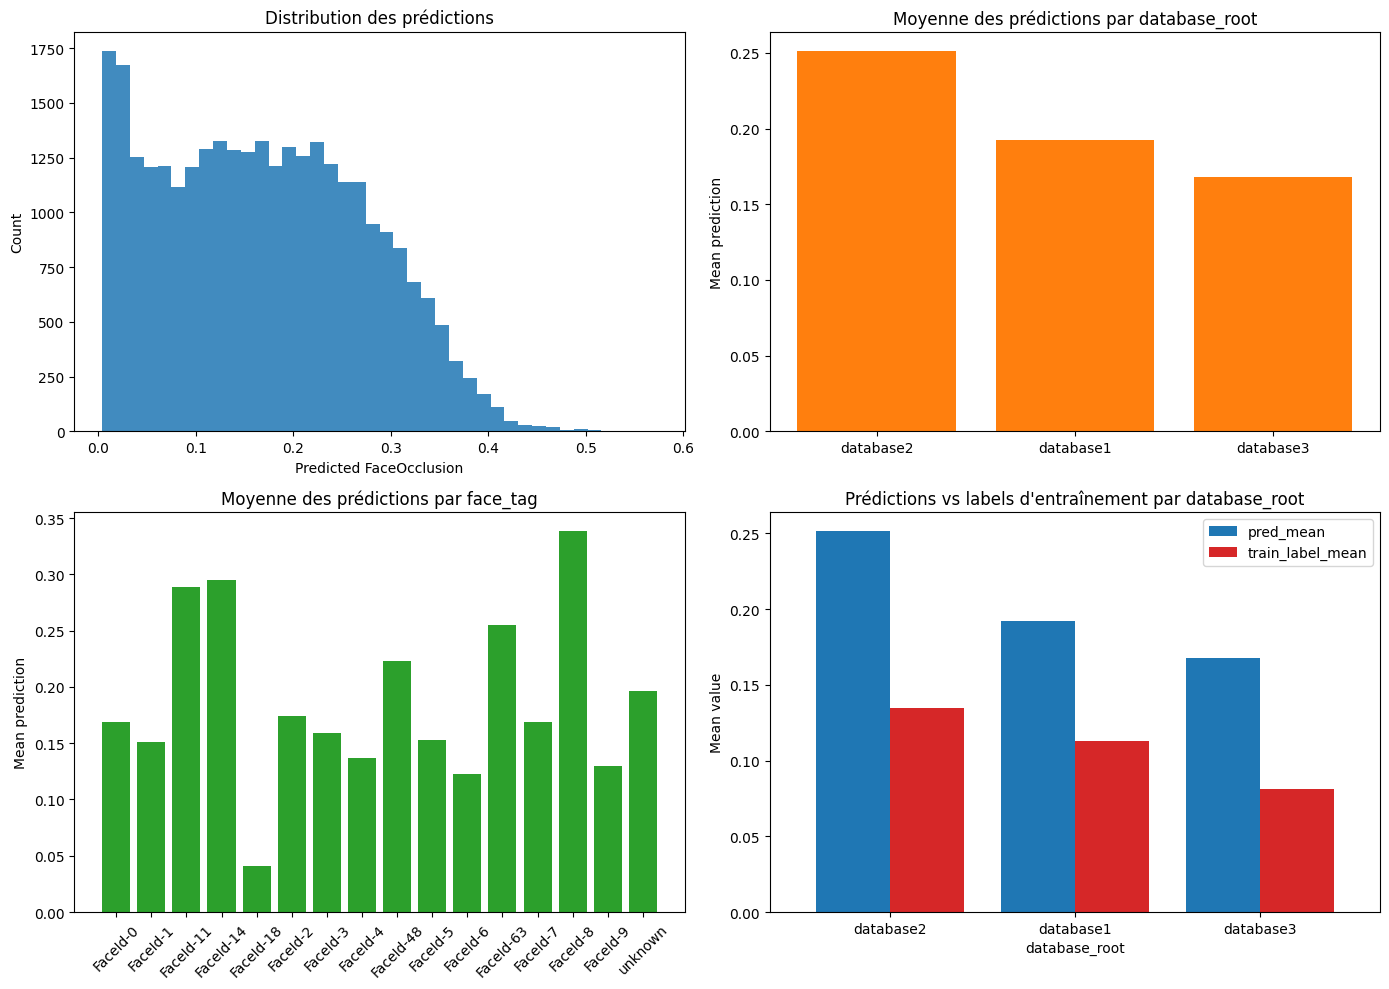

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(preds['pred'], bins=40, color='#1f77b4', alpha=0.85)
axes[0, 0].set_title('Distribution des prédictions')
axes[0, 0].set_xlabel('Predicted FaceOcclusion')
axes[0, 0].set_ylabel('Count')

root_means = preds.groupby('database_root')['pred'].mean().sort_values(ascending=False)
axes[0, 1].bar(root_means.index, root_means.values, color='#ff7f0e')
axes[0, 1].set_title('Moyenne des prédictions par database_root')
axes[0, 1].set_ylabel('Mean prediction')

face_means = preds.groupby('face_tag')['pred'].mean().sort_index()
axes[1, 0].bar(face_means.index, face_means.values, color='#2ca02c')
axes[1, 0].set_title('Moyenne des prédictions par face_tag')
axes[1, 0].set_ylabel('Mean prediction')
axes[1, 0].tick_params(axis='x', rotation=45)

train_root_means = train.groupby('database_root')['FaceOcclusion'].mean().sort_values(ascending=False)
comparison = pd.DataFrame({'pred_mean': root_means, 'train_label_mean': train_root_means})
comparison.plot(kind='bar', ax=axes[1, 1], width=0.8, color=['#1f77b4', '#d62728'])
axes[1, 1].set_title('Prédictions vs labels d\'entraînement par database_root')
axes[1, 1].set_ylabel('Mean value')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Synthèse opérationnelle

Les sorties de `dinov3-vitb16_run002` montrent un modèle assez conservateur sur la masse principale, avec une moyenne de prédiction autour de `0.17` et une queue haute très fine : presque aucune prédiction au-dessus de `0.50`. Le run est donc surtout bon pour discriminer les cas faibles à intermédiaires, mais il reste prudent sur les fortes occlusions.

Deux points ressortent pour la suite :

- Les prédictions sont systématiquement plus élevées que les moyennes observées sur l'entraînement pour `database3`, `database1` et `database2`. Le décalage est particulièrement visible pour `database2`, ce qui en fait un sous-ensemble à inspecter en priorité.
- Les groupes `FaceId-8`, `FaceId-11`, `FaceId-14` et `FaceId-63` affichent des moyennes très élevées, mais avec un effectif trop faible pour en tirer une règle stable. Ce sont surtout des candidats pour une revue manuelle d'images.

Pour exploiter ce notebook ensuite, les deux prochains axes utiles sont :

1. extraire les images du top des prédictions pour vérifier visuellement les faux positifs probables ;
2. ajouter, si un jeu de validation avec labels est exporté plus tard, le calcul direct des résidus par sous-groupe avec le même découpage `database_root` / `face_tag`.
